In [1]:
import pandas as pd
import numpy as np
import os
import sys; sys.path.append("/data/jerrylee/pjt/BIGFAM.v.0.1")
from BIGFAM import tools
from BIGFAM.obj1 import _slopeSig

import seaborn as sns
import matplotlib.pyplot as plt; plt.style.use("dark_background")
import statsmodels.formula.api as smf

In [ ]:
sources = ["UKB", "GS"]

# Step 1. FRLog-reg

In [5]:
# filiter out phenotype which has too small n_pair
df_ps = pd.DataFrame(columns=["cohort", "pheno"])

# pheno list
for src in sources:
    frreg_path = f"/data/jerrylee/pjt/BIGFAM.v.0.1/data/{src}/frreg/DOR"
    p_fns = os.listdir(frreg_path)
    
    for p in p_fns:
        if p == "tmp":
            continue
        fn = frreg_path + "/" + p
        tmp = pd.read_csv(fn, sep='\t')
        
        if sum(tmp["n"] < 200): # less than 100 pairs
            continue
        
        df_ps.loc[len(df_ps)] = [src, p.split(".")[0]]

In [6]:
# load FRlogreg
df_frlog_mrg = pd.DataFrame()
for src in sources:
    frlog_path = f"/data/jerrylee/pjt/BIGFAM.v.0.1/data/{src}/FRLogreg"
    fns = os.listdir(frlog_path)
    fns = [fn for fn in fns if fn.split(".")[-1] == "FRLOG"]
    
    tmp_frlog = pd.DataFrame()
    for fn in fns:
        p = fn.split(".")[0]
        
        if p == "tmp":
            continue
        
        if p not in df_ps.loc[df_ps["cohort"] == src, "pheno"].to_list():
            continue
            
        # load FRLog-reg results
        frlog_fn = f"{frlog_path}/{fn}"
        df_slopetest = pd.read_csv(frlog_fn, sep='\t')
        df_slopetest_wide = tools.long2wide(df_slopetest)
        
        # annotation
        df_slopetest_wide["pheno"] = p
        df_slopetest_wide["sig"] = "None"
        if (df_slopetest_wide["lower_slope"].values[0] > 1):
            df_slopetest_wide["sig"] = "High"
        if (df_slopetest_wide["upper_slope"].values[0] < 1):
            df_slopetest_wide["sig"] = "Low"
        
        tmp_frlog = pd.concat([tmp_frlog, df_slopetest_wide], axis=0)
    
    tmp_frlog["cohort"] = src
    df_frlog_mrg = (pd.concat([df_frlog_mrg, tmp_frlog], axis=0)
                    .reset_index(drop=True))

df_frlog_mrg

,slope,lower_slope,upper_slope,intercept,lower_intercept,upper_intercept,pheno,sig,cohort
0,0.931290,0.890439,0.980765,-0.971320,-1.045296,-0.889537,Body_mass_index__BMI_,Low,UKB
1,1.023568,0.905393,1.115254,-1.754704,-1.973401,-1.636776,Creatinine,None,UKB
2,0.945760,0.890510,1.004999,-1.118566,-1.222833,-1.017913,Impedance_of_arm__right_,None,UKB
3,1.203189,1.124266,1.288758,-0.671934,-0.804818,-0.550196,Impedance_of_leg__left_,High,UKB
4,0.918686,0.873524,0.973581,-1.309409,-1.411195,-1.218170,IGF-1,Low,UKB
...,...,...,...,...,...,...,...,...,...
132,0.695063,0.445427,1.175181,-1.917459,-2.297175,-1.212950,FEF,None,GS
133,0.583399,0.360261,0.877438,-2.265984,-2.550094,-1.853216,Heart_Rate,Low,GS
134,0.665226,0.556894,0.778570,-0.603474,-0.755549,-0.456458,expected,Low,GS
135,0.513359,0.282105,0.780702,-2.265010,-2.595991,-1.881057,max_leg,Low,GS


In [7]:
df_frlog_mrg.to_csv(
    f"/data/jerrylee/pjt/BIGFAM.v.0.1/figures/data/frlogreg.v3.tsv",
    sep='\t',
    index=False)

## Step 1.1 check

In [8]:
df_frlog_mrg = pd.read_csv(
    f"/data/jerrylee/pjt/BIGFAM.v.0.1/figures/data/frlogreg.v3.tsv",
    sep='\t',
)
df_frlog_mrg.shape

(137, 9)

In [9]:
df_frlog_mrg.groupby(["sig"]).size()

sig
High    18
Low     53
None    66
dtype: int64

In [23]:
71/137

0.5182481751824818

In [10]:
df_frlog_mrg.groupby(["cohort", "sig"]).size()

cohort  sig 
GS      Low     14
        None    14
UKB     High    18
        Low     39
        None    52
dtype: int64

# Step 2. Prediction (obj1)

In [11]:
# functions to load data
def load_bigfam(path):
    pheno_fns = os.listdir(path)
    phenos = [pheno_fn.split(".")[0] for pheno_fn in pheno_fns]
    phenos = set(phenos)
    
    df_bigfam = pd.DataFrame()
    for pheno in phenos:
        try:
            tmp = pd.read_csv(f"{path}/{pheno}.GSW", sep='\t')
            tmp["param"] = ["G_BIGFAM", "S_BIGFAM", "w_BIGFAM", "mse_train", "mse_test"]
            tmp_wide = tools.long2wide(tmp)
            
            tmp_sig = pd.read_csv(f"{path}/{pheno}.FRLOG_raw", sep='\t')
            sig = _slopeSig(tmp_sig["slope"])
            tmp_wide["pheno"] = pheno
            tmp_wide["sig"] = sig
            
            df_bigfam = pd.concat([df_bigfam, tmp_wide], axis=0)
        except:
            continue
    
    return df_bigfam.reset_index(drop=True)

In [12]:
# load FRlogreg
df_pred = pd.DataFrame()

for src in sources:
    pred_path = f"/data/jerrylee/pjt/BIGFAM.v.0.1/data/{src}/obj1"
    frlog_path = f"/data/jerrylee/pjt/BIGFAM.v.0.1/data/{src}/FRLogreg"
    fns = os.listdir(pred_path)
    fns = [fn for fn in fns if fn.split(".")[-1] == "GSW"]
    
    tmp_pred = pd.DataFrame()
    for fn in fns:
        p = fn.split(".")[0]
        
        if p == "tmp":
            continue
        
        if p not in df_ps.loc[df_ps["cohort"] == src, "pheno"].to_list():
            continue
            
        # load FRLog-reg results
        pred_fn = f"{pred_path}/{fn}"
        tmp = pd.read_csv(pred_fn, sep='\t')
        tmp["param"] = ["G_BIGFAM", "S_BIGFAM", "w_BIGFAM", "mse_train", "mse_test"]
        tmp_wide = tools.long2wide(tmp)
        tmp_sig = pd.read_csv(f"{frlog_path}/{p}.FRLOG_raw", sep='\t')
        sig = _slopeSig(tmp_sig["slope"])
        tmp_wide["pheno"] = p
        tmp_wide["sig"] = sig
        
        tmp_pred = pd.concat([tmp_pred, tmp_wide], axis=0)
    
    tmp_pred["cohort"] = src
    df_pred = (pd.concat([df_pred, tmp_pred], axis=0)
               .reset_index(drop=True))

df_pred

,G_BIGFAM,lower_G_BIGFAM,upper_G_BIGFAM,S_BIGFAM,lower_S_BIGFAM,upper_S_BIGFAM,w_BIGFAM,lower_w_BIGFAM,upper_w_BIGFAM,mse_train,lower_mse_train,upper_mse_train,mse_test,lower_mse_test,upper_mse_test,pheno,sig,cohort
0,0.625072,0.623822,0.626010,0.012932,0.012664,0.013163,0.95,0.95,0.95000,1.430399,1.360756,1.483043,0.156647,0.104312,0.226269,Whole_body_water_mass,Low,UKB
1,0.157405,0.156654,0.158337,0.017552,0.017325,0.017741,0.95,0.95,0.95000,20.133582,19.069972,20.791932,2.188345,1.532388,3.257606,Monocyte_count,Low,UKB
2,0.262343,0.205391,0.284595,0.013680,0.000001,0.041641,0.46,0.40,0.58000,2.601725,2.431669,2.749792,0.278115,0.171268,0.416885,Creatinine,None,UKB
3,0.202208,0.046325,0.208625,0.041501,0.040553,0.121528,0.48,0.43,0.48525,4.130742,3.922101,4.482038,0.457043,0.243451,0.669903,Calcium,None,UKB
4,0.458526,0.457183,0.459740,0.037280,0.037027,0.037622,0.95,0.95,0.95000,2.561443,2.426515,2.650125,0.279119,0.190487,0.414052,"Forced_vital_capacity__FVC_,_Best_measure",Low,UKB
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
132,0.047042,0.046071,0.048351,0.015151,0.014835,0.015570,0.95,0.95,0.95000,833.966561,750.808537,862.215724,83.713839,55.554596,167.051112,T_axis,Low,GS
133,0.000001,0.000001,0.000001,0.063167,0.061914,0.064850,0.40,0.40,0.40000,382.909334,267.445223,403.068292,25.987279,7.226596,141.560514,LVMI_Rautaharju,None,GS
134,0.000001,0.000001,0.000001,0.124993,0.124266,0.127754,0.60,0.59,0.60000,92.576489,89.452630,94.743184,10.079738,8.043344,13.158275,Total_cholesterol,None,GS
135,0.000001,0.000001,0.000001,0.168837,0.167901,0.182167,0.60,0.56,0.60000,20.704213,18.631752,23.379026,2.165544,1.036677,4.115349,FEF,None,GS


In [13]:
df_pred.to_csv(
    f"/data/jerrylee/pjt/BIGFAM.v.0.1/figures/data/obj1.v3.tsv",
    sep='\t',
    index=False)

## Step 2.1 check

In [14]:
df_pred = pd.read_csv(
    "/data/jerrylee/pjt/BIGFAM.v.0.1/figures/data/obj1.v3.tsv",
    sep='\t',
)
df_pred.shape

(137, 18)

In [15]:
# tt = df_pred[(df_pred["lower_G_BIGFAM"] > 1e-6) & (df_pred["lower_S_BIGFAM"] > 1e-6)].copy()
tt = df_pred[(df_pred["lower_G_BIGFAM"] > 1e-6)].copy()
tt["ww_BIGFAM"] = 1 / tt["w_BIGFAM"]
tt.shape

(102, 19)

In [16]:
tt[["G_BIGFAM", "S_BIGFAM", "ww_BIGFAM"]].agg(["mean", "std", "size"])

,G_BIGFAM,S_BIGFAM,ww_BIGFAM
mean,0.333444,0.039610,10.519158
std,0.172199,0.042388,28.056527
size,102.000000,102.000000,102.000000


In [17]:
tt.groupby("sig")[["G_BIGFAM", "S_BIGFAM", "ww_BIGFAM"]].agg(["mean", "std", "size"])

G_BIGFAM                 S_BIGFAM                 ww_BIGFAM             \
          mean       std size      mean       std size       mean        std   
sig                                                                            
High  0.328485  0.151645   13  0.057043  0.060402   13  71.888293  44.127473   
Low   0.352074  0.196939   47  0.041693  0.046821   47   1.131065   0.220010   
None  0.314131  0.148367   42  0.031883  0.027133   42   2.029673   0.362472   

           
     size  
sig        
High   13  
Low    47  
None   42

In [18]:
tt.groupby(["cohort", "sig"])[["G_BIGFAM", "S_BIGFAM", "ww_BIGFAM"]].agg(["mean", "std", "size"])

G_BIGFAM                 S_BIGFAM                 ww_BIGFAM  \
                 mean       std size      mean       std size       mean   
cohort sig                                                                 
GS     Low   0.204269  0.187333   11  0.058175  0.026896   11   1.052632   
       None  0.204696       NaN    1  0.040359       NaN    1   2.083333   
UKB    High  0.328485  0.151645   13  0.057043  0.060402   13  71.888293   
       Low   0.397237  0.178840   36  0.036657  0.050627   36   1.155031   
       None  0.316800  0.149186   41  0.031676  0.027437   41   2.028364   

                             
                   std size  
cohort sig                   
GS     Low    0.000000   11  
       None        NaN    1  
UKB    High  44.127473   13  
       Low    0.247170   36  
       None   0.366875   41

In [19]:
tt[tt["sig"] == "High"].sort_values(by=["w_BIGFAM", "upper_w_BIGFAM"])[["pheno", "w_BIGFAM", "upper_w_BIGFAM"]]

,pheno,w_BIGFAM,upper_w_BIGFAM
5,SHBG,0.010,0.01000
29,Hip_circumference,0.010,0.01000
31,Impedance_of_whole_body,0.010,0.01000
41,Arm_fat_mass__right_,0.010,0.01000
64,Aspartate_aminotransferase,0.010,0.01000
108,Arm_fat_mass__left_,0.010,0.01000
23,Glycated_haemoglobin__HbA1c_,0.010,0.02525
66,Total_bilirubin,0.010,0.02525
33,Red_blood_cell__erythrocyte__distribution_width,0.010,0.12525
67,Alanine_aminotransferase,0.045,0.13000


In [20]:
tt.sort_values(by=["S_BIGFAM"])

,G_BIGFAM,lower_G_BIGFAM,upper_G_BIGFAM,S_BIGFAM,lower_S_BIGFAM,upper_S_BIGFAM,w_BIGFAM,lower_w_BIGFAM,upper_w_BIGFAM,mse_train,lower_mse_train,upper_mse_train,mse_test,lower_mse_test,upper_mse_test,pheno,sig,cohort,ww_BIGFAM
92,0.322178,0.225172,0.324078,0.005307,0.003914,0.050074,0.47,0.400,0.600,7.051285,6.760856,7.369593,0.773067,0.497061,1.047143,Apolipoprotein_B,None,UKB,2.127660
85,0.033828,0.033167,0.038136,0.006763,0.006603,0.007258,0.60,0.450,0.600,326.790541,289.187266,346.542433,32.378976,13.357896,70.323395,Interpolated_Age_of_participant_when_non-cance...,None,UKB,1.666667
12,0.313111,0.224734,0.327463,0.006810,0.001444,0.052890,0.60,0.419,0.600,4.798834,4.547196,5.066990,0.522822,0.335620,0.822755,Neutrophill_count,None,UKB,1.666667
71,0.034139,0.031312,0.040188,0.006824,0.002858,0.006941,0.40,0.400,0.571,487.988047,456.549439,512.333813,53.425814,29.145449,85.730406,Basophill_percentage,None,UKB,2.500000
61,0.311496,0.223858,0.322385,0.007039,0.003850,0.048520,0.60,0.400,0.600,9.193387,8.900769,9.514308,1.011989,0.714981,1.353325,Haemoglobin_concentration,None,UKB,1.666667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69,0.221610,0.166686,0.442023,0.119918,0.011293,0.146952,0.56,0.550,0.950,0.661117,0.614295,0.706679,0.069872,0.037825,0.123644,Mean_corpuscular_haemoglobin,Low,UKB,1.785714
80,0.018829,0.008358,0.310659,0.156313,0.012393,0.161359,0.55,0.550,0.950,1.209083,1.148205,1.262819,0.131056,0.069741,0.206945,Hand_grip_strength__left_,Low,UKB,1.818182
7,0.124070,0.112879,0.333197,0.174257,0.066659,0.179778,0.48,0.470,0.480,6.018401,5.841076,6.232745,0.665333,0.528138,0.828368,Alkaline_phosphatase,None,UKB,2.083333
51,0.567949,0.257959,0.733260,0.244915,0.164181,0.398178,0.70,0.630,0.780,0.077998,0.071336,0.090949,0.007379,0.004447,0.014662,Standing_height,Low,UKB,1.428571


In [21]:
tt[tt["pheno"] == "Impedance_of_leg__right_"][["pheno", "G_BIGFAM", "S_BIGFAM", "ww_BIGFAM"]]

,pheno,G_BIGFAM,S_BIGFAM,ww_BIGFAM
103,Impedance_of_leg__right_,0.050981,0.255088,2.325581


In [22]:
tt[tt["pheno"] == "Standing_height"][["pheno", "G_BIGFAM", "S_BIGFAM", "ww_BIGFAM"]]

,pheno,G_BIGFAM,S_BIGFAM,ww_BIGFAM
51,Standing_height,0.567949,0.244915,1.428571


# Step 3. PC vs. SB

## Step 3.1 GS

In [116]:
frlog_path = "/data/jerrylee/pjt/BIGFAM.v.0.1/data/GS/po-sib/FRLogreg"
pred_path = "/data/jerrylee/pjt/BIGFAM.v.0.1/data/GS/po-sib/obj1"
fns = os.listdir(pred_path)

phenos = list(set([fn.split(".")[0] for fn in fns]))

In [117]:
df_gs = pd.DataFrame(columns=["pheno", "subgroup", "sig", "parameter", "median", "lower", "upper"])

for pheno in phenos:
    for subgroup in ["PC", "SB"]:
        # load data
        df_frlogreg = pd.read_csv(f"{frlog_path}/{pheno}.{subgroup}.FRLOG", sep='\t')
        slp, lower_slp, upper_slp = df_frlogreg.loc[df_frlogreg["param"] == "slope", ["median", "lower(2.5%)", "upper(97.5%)"]].values[0]
        sig = "None"
        if lower_slp > 1:
            sig = "High"
        elif upper_slp < 1:
            sig = "Low"
        
        df_pred = pd.read_csv(f"{pred_path}/{pheno}.{subgroup}.GSW", sep='\t')
        Vg, lower_Vg, upper_Vg = df_pred.loc[df_pred["param"] == "V(g)", ["median", "lower(2.5%)", "upper(97.5%)"]].values[0]
        Vs, lower_Vs, upper_Vs = df_pred.loc[df_pred["param"] == "V(s)", ["median", "lower(2.5%)", "upper(97.5%)"]].values[0]
        w, lower_w, upper_w = df_pred.loc[df_pred["param"] == "w", ["median", "lower(2.5%)", "upper(97.5%)"]].values[0]
        
        df_gs.loc[len(df_gs)] = [pheno, subgroup, sig, "Vg", Vg, lower_Vg, upper_Vg]
        df_gs.loc[len(df_gs)] = [pheno, subgroup, sig, "Vs", Vs, lower_Vs, upper_Vs]
        df_gs.loc[len(df_gs)] = [pheno, subgroup, sig, "w", w, lower_w, upper_w]


In [118]:
df_gs.groupby(["pheno", "sig", "subgroup"]).size()

pheno              sig   subgroup
Creat_mgdl         Low   PC          3
                   None  SB          3
Creatinine         Low   PC          3
                   None  SB          3
FEF                None  PC          3
                         SB          3
FEV                Low   PC          3
                   None  SB          3
FVC                Low   PC          3
                         SB          3
Glucose            None  PC          3
                         SB          3
HDL_cholesterol    Low   PC          3
                   None  SB          3
Heart_Rate         Low   PC          3
                         SB          3
LVMI_Fhuwez        None  PC          3
                         SB          3
LVMI_Rautaharju    High  SB          3
                   None  PC          3
Potassium          None  PC          3
                         SB          3
QRS_axis           Low   PC          3
                   None  SB          3
QRS_duration       None  PC   

## Step 3.2 UKB

In [287]:
frlog_path = "/data/jerrylee/pjt/BIGFAM.v.0.1/data/UKB/po-sib/FRLogreg"
pred_path = "/data/jerrylee/pjt/BIGFAM.v.0.1/data/UKB/po-sib/obj1"
fns = os.listdir(pred_path)

phenos = list(set([fn.split(".")[0] for fn in fns]))

In [288]:
df_ukb = pd.DataFrame(columns=["pheno", "subgroup", "sig", "parameter", "median", "lower", "upper"])

for pheno in phenos:
    for subgroup in ["PC", "SB"]:
        # load data
        df_frlogreg = pd.read_csv(f"{frlog_path}/{pheno}.{subgroup}.FRLOG", sep='\t')
        slp, lower_slp, upper_slp = df_frlogreg.loc[df_frlogreg["param"] == "slope", ["median", "lower(2.5%)", "upper(97.5%)"]].values[0]
        sig = "None"
        if lower_slp > 1:
            sig = "High"
        elif upper_slp < 1:
            sig = "Low"
        
        df_pred = pd.read_csv(f"{pred_path}/{pheno}.{subgroup}.GSW", sep='\t')
        Vg, lower_Vg, upper_Vg = df_pred.loc[df_pred["param"] == "V(g)", ["median", "lower(2.5%)", "upper(97.5%)"]].values[0]
        Vs, lower_Vs, upper_Vs = df_pred.loc[df_pred["param"] == "V(s)", ["median", "lower(2.5%)", "upper(97.5%)"]].values[0]
        w, lower_w, upper_w = df_pred.loc[df_pred["param"] == "w", ["median", "lower(2.5%)", "upper(97.5%)"]].values[0]
        
        df_ukb.loc[len(df_ukb)] = [pheno, subgroup, sig, "Vg", Vg, lower_Vg, upper_Vg]
        df_ukb.loc[len(df_ukb)] = [pheno, subgroup, sig, "Vs", Vs, lower_Vs, upper_Vs]
        df_ukb.loc[len(df_ukb)] = [pheno, subgroup, sig, "w", w, lower_w, upper_w]

In [289]:
df_ukb.groupby(["pheno", "sig", "subgroup"]).size()

pheno                     sig   subgroup
Alanine_aminotransferase  High  SB          3
                          None  PC          3
Albumin                   Low   PC          3
                          None  SB          3
Alkaline_phosphatase      None  PC          3
                                           ..
Whole_body_fat-free_mass  None  SB          3
Whole_body_fat_mass       None  PC          3
                                SB          3
Whole_body_water_mass     Low   PC          3
                          None  SB          3
Length: 206, dtype: int64

## Step 3.3 merge

In [290]:
df_ukb_formatted = pd.DataFrame(columns=["pheno", "parameter",
                                         "pc", "lower_pc", "upper_pc", "sig_pc",
                                         "sb", "lower_sb", "upper_sb", "sig_sb", "matching_w"])
for pheno in df_ukb["pheno"].unique():
    tmp = df_ukb[df_ukb["pheno"] == pheno]
    
    # validate (each phenotype has info from both PC, SB)
    if len(tmp) != 6:
        print(pheno)
        continue
    
    tmp_pc = tmp[tmp["subgroup"] == "PC"]
    tmp_sb = tmp[tmp["subgroup"] == "SB"]
    matching_w = True
    
    for ii, param in enumerate(["Vg", "Vs", "w"]):
        pc, lower_pc, upper_pc, sig_pc = tmp_pc.loc[tmp_pc["parameter"] == param, ["median", "lower", "upper", "sig"]].values[0]
        sb, lower_sb, upper_sb, sig_sb = tmp_sb.loc[tmp_sb["parameter"] == param, ["median", "lower", "upper", "sig"]].values[0]
        
        if (ii == 0) & (sig_pc != sig_sb):
            print(f"[{pheno}], (PC, SB) = ({sig_pc}, {sig_sb})")
            matching_w = False
            
        
        if param == "w":
            df_ukb_formatted.loc[len(df_ukb_formatted)] = [pheno, "1/w", 
                                                       1/pc, 1/lower_pc, 1/ upper_pc, sig_pc,
                                                       1/sb, 1/lower_sb, 1/upper_sb, sig_sb, matching_w]
            df_ukb_formatted.loc[len(df_ukb_formatted)] = [pheno, "w", 
                                                       pc, lower_pc, upper_pc, sig_pc,
                                                       sb, lower_sb, upper_sb, sig_sb, matching_w]
        else:
            df_ukb_formatted.loc[len(df_ukb_formatted)] = [pheno, param,
                                                       pc, lower_pc, upper_pc, sig_pc,
                                                       sb, lower_sb, upper_sb, sig_sb, matching_w]
            
    
df_ukb_formatted["cohort"] = "UKB"

[Mean_corpuscular_haemoglobin_concentration], (PC, SB) = (High, None)
[IGF-1], (PC, SB) = (Low, None)
[Heel_bone_mineral_density__BMD__T-score,_automated], (PC, SB) = (None, High)
[Urea], (PC, SB) = (Low, None)
[Mean_reticulocyte_volume], (PC, SB) = (High, None)
[Haemoglobin_concentration], (PC, SB) = (Low, None)


[Red_blood_cell__erythrocyte__distribution_width], (PC, SB) = (None, High)
[Platelet_count], (PC, SB) = (None, High)
[Mean_platelet__thrombocyte__volume], (PC, SB) = (None, High)
[Aspartate_aminotransferase], (PC, SB) = (None, High)
[Arm_predicted_mass__left_], (PC, SB) = (Low, None)
[Hip_circumference], (PC, SB) = (High, None)
[Body_mass_index__BMI_], (PC, SB) = (None, Low)
[Reticulocyte_percentage], (PC, SB) = (High, None)
[Arm_predicted_mass__right_], (PC, SB) = (Low, None)
[Urate], (PC, SB) = (None, High)
[Hand_grip_strength__left_], (PC, SB) = (Low, None)
[Phosphate], (PC, SB) = (Low, None)
[Trunk_fat_percentage], (PC, SB) = (Low, None)
[High_light_scatter_reticulocyte_count], (PC, SB) = (None, Low)
[Total_bilirubin], (PC, SB) = (None, High)
[Eosinophill_percentage], (PC, SB) = (None, Low)
[Basophill_percentage], (PC, SB) = (High, None)
[Cystatin_C], (PC, SB) = (None, High)
[Total_protein], (PC, SB) = (Low, None)
[Albumin], (PC, SB) = (Low, None)
[Arm_fat_percentage__right_], (PC,

In [291]:
# onlt [Apolipoprotein_B], (PC, SB) = (Low, High)

In [292]:
df_ukb_formatted

,pheno,parameter,pc,lower_pc,upper_pc,sig_pc,sb,lower_sb,upper_sb,sig_sb,matching_w,cohort
0,Mean_corpuscular_haemoglobin_concentration,Vg,0.132557,0.000001,0.177605,High,0.000001,0.000001,0.005384,None,False,UKB
1,Mean_corpuscular_haemoglobin_concentration,Vs,0.074449,0.053398,0.136886,High,0.104903,0.101242,0.106673,None,False,UKB
2,Mean_corpuscular_haemoglobin_concentration,1/w,0.266516,0.403226,0.102739,High,0.458971,0.481085,0.457698,None,False,UKB
3,Mean_corpuscular_haemoglobin_concentration,w,3.752121,2.480000,9.733394,High,2.178788,2.078636,2.184848,None,False,UKB
4,IGF-1,Vg,0.329902,0.328391,0.331294,Low,0.271275,0.267856,0.274775,None,False,UKB
...,...,...,...,...,...,...,...,...,...,...,...,...
407,Apolipoprotein_B,w,1.415152,1.398990,1.475960,Low,118.920000,118.920000,118.920000,High,False,UKB
408,Lipoprotein_A,Vg,0.289036,0.283510,0.294889,High,0.158986,0.154065,0.163754,High,True,UKB
409,Lipoprotein_A,Vs,0.235495,0.232202,0.238602,High,0.324734,0.322008,0.327918,High,True,UKB
410,Lipoprotein_A,1/w,0.403226,0.403226,0.403226,High,0.403226,0.403226,0.403226,High,True,UKB


In [293]:
df_gs_formatted = pd.DataFrame(columns=["pheno", "parameter",
                                         "pc", "lower_pc", "upper_pc", "sig_pc",
                                         "sb", "lower_sb", "upper_sb", "sig_sb", "matching_w"])
for pheno in df_gs["pheno"].unique():
    tmp = df_gs[df_gs["pheno"] == pheno]
    
    # validate (each phenotype has info from both PC, SB)
    if len(tmp) != 6:
        print(pheno)
        continue
    
    tmp_pc = tmp[tmp["subgroup"] == "PC"]
    tmp_sb = tmp[tmp["subgroup"] == "SB"]
    matching_w = True
    
    for ii, param in enumerate(["Vg", "Vs", "w"]):
        pc, lower_pc, upper_pc, sig_pc = tmp_pc.loc[tmp_pc["parameter"] == param, ["median", "lower", "upper", "sig"]].values[0]
        sb, lower_sb, upper_sb, sig_sb = tmp_sb.loc[tmp_sb["parameter"] == param, ["median", "lower", "upper", "sig"]].values[0]
        
        if (ii == 0) & (sig_pc != sig_sb):
            print(f"[{pheno}], (PC, SB) = ({sig_pc}, {sig_sb})")
            matching_w = False
        
        if param == "w":
            df_gs_formatted.loc[len(df_gs_formatted)] = [pheno, "w", 
                                                       1/pc, 1/lower_pc, 1/ upper_pc, sig_pc,
                                                       1/sb, 1/lower_sb, 1/upper_sb, sig_sb, matching_w]
            df_gs_formatted.loc[len(df_gs_formatted)] = [pheno, "1/w", 
                                                       pc, lower_pc, upper_pc, sig_pc,
                                                       sb, lower_sb, upper_sb, sig_sb, matching_w]
        else:
            df_gs_formatted.loc[len(df_gs_formatted)] = [pheno, param,
                                                       pc, lower_pc, upper_pc, sig_pc,
                                                       sb, lower_sb, upper_sb, sig_sb, matching_w]

    
df_gs_formatted["cohort"] = "GS"

[avg_sys], (PC, SB) = (Low, None)
[T_axis], (PC, SB) = (Low, None)
[QRS_axis], (PC, SB) = (Low, None)
[Creatinine], (PC, SB) = (Low, None)
[QTC_interval], (PC, SB) = (None, Low)
[HDL_cholesterol], (PC, SB) = (Low, None)
[LVMI_Rautaharju], (PC, SB) = (None, High)
[FEV], (PC, SB) = (Low, None)
[Creat_mgdl], (PC, SB) = (Low, None)
[Total_cholesterol], (PC, SB) = (Low, None)


In [294]:
df_gs_formatted

,pheno,parameter,pc,lower_pc,upper_pc,sig_pc,sb,lower_sb,upper_sb,sig_sb,matching_w,cohort
0,FEF,Vg,0.000001,0.000001,0.016540,None,0.020647,0.000001,0.039265,None,True,GS
1,FEF,Vs,0.162517,0.154548,0.175079,None,0.164214,0.155411,0.188045,None,True,GS
2,FEF,w,1.666667,1.785714,1.666667,None,1.666667,1.802614,1.666667,None,True,GS
3,FEF,1/w,0.600000,0.560000,0.600000,None,0.600000,0.554750,0.600000,None,True,GS
4,avg_sys,Vg,0.037259,0.035394,0.038909,Low,0.008523,0.000001,0.014952,None,False,GS
...,...,...,...,...,...,...,...,...,...,...,...,...
107,Sodium,1/w,0.800000,0.780000,0.810000,Low,0.920000,0.720000,0.950000,Low,True,GS
108,QT_interval,Vg,0.000001,0.000001,0.000001,None,0.128235,0.000001,0.139580,None,True,GS
109,QT_interval,Vs,0.141256,0.140608,0.142101,None,0.101400,0.096038,0.176670,None,True,GS
110,QT_interval,w,1.666667,1.666667,1.666667,None,1.666667,1.886792,1.666667,None,True,GS


In [295]:
df_mrg = (pd.concat([df_ukb_formatted, df_gs_formatted], axis=0)
           .reset_index(drop=True))


In [296]:
df_mrg["sig"] = "None"

df_mrg.loc[df_mrg["matching_w"] == True, "sig"] = df_mrg["sig_pc"]

In [297]:
df_mrg.to_csv("/data/jerrylee/pjt/BIGFAM.v.0.1/figures/data/obj1.PC-SB.tsv",
              sep='\t',
              index=False)

In [298]:
df_filtered = pd.DataFrame()

for _, row in df_mrg[(df_mrg["parameter"] == "Vg") & (df_mrg["lower_pc"] > 1e-6) & (df_mrg["lower_sb"] > 1e-6)].iterrows():
    p, cohort = row[["pheno", "cohort"]]
    tmp = df_mrg[(df_mrg["pheno"] == p) & (df_mrg["cohort"] == cohort)]
    
    # if len(tmp)
    df_filtered = pd.concat([df_filtered, tmp], axis=0)
    

In [299]:
df_filtered.to_csv(
    "/data/jerrylee/pjt/BIGFAM.v.0.1/figures/data/obj1.PC-SB.filtered.tsv",
    sep='\t',
    index=False)

check

In [300]:
(df_filtered
 .groupby(["cohort", "pheno"])
 .size()
 .to_frame("cnt")
 .reset_index())

,cohort,pheno,cnt
0,GS,FVC,4
1,GS,Heart_Rate,4
2,GS,QRS_axis,4
3,GS,Total_cholesterol,4
4,GS,abpi,4
...,...,...,...
68,UKB,Waist_circumference,4
69,UKB,Weight,4
70,UKB,Whole_body_fat-free_mass,4
71,UKB,Whole_body_fat_mass,4


In [301]:
df_filtered.groupby("sig").size() / 4

sig
High     6.0
Low     18.0
None    49.0
dtype: float64

In [319]:
24/73

0.3287671232876712

In [303]:
df_filtered.groupby(["cohort", "sig"]).size() / 4

cohort  sig 
GS      Low      6.0
        None     3.0
UKB     High     6.0
        Low     12.0
        None    46.0
dtype: float64

In [304]:
df_filtered[df_filtered["parameter"] == "Vg"].agg(["mean", "std"])

,pc,lower_pc,upper_pc,sb,lower_sb,upper_sb,matching_w
mean,0.337674,0.310662,0.353307,0.372658,0.342843,0.379997,0.493151
std,0.156260,0.160670,0.157730,0.168376,0.160892,0.167728,0.503413


In [305]:
df_filtered[df_filtered["parameter"] == "Vs"].agg(["mean", "std"])

,pc,lower_pc,upper_pc,sb,lower_sb,upper_sb,matching_w
mean,0.048038,0.040370,0.061026,0.049527,0.046583,0.064541,0.493151
std,0.039289,0.038504,0.047174,0.050854,0.051273,0.050709,0.503413


In [306]:
from scipy.stats import pearsonr

In [320]:
tmp = (df_filtered[df_filtered["parameter"] == "Vg"][["pheno", "cohort", "pc", "sb"]])
pearsonr(tmp["pc"], tmp["sb"])

PearsonRResult(statistic=0.8985376892925416, pvalue=4.241681606157005e-27)

In [321]:
tmp = (df_filtered[df_filtered["parameter"] == "Vs"][["pheno", "cohort", "pc", "sb"]])
pearsonr(tmp["pc"], tmp["sb"])

PearsonRResult(statistic=0.8350614979162014, pvalue=4.21742100412206e-20)

In [309]:
tmp = (df_filtered[df_filtered["parameter"] == "1/w"][["pheno", "cohort", "pc", "sb"]])
pearsonr(tmp["pc"], tmp["sb"])

PearsonRResult(statistic=0.6068974829508726, pvalue=1.257549901323658e-08)

In [310]:
(df_filtered[df_filtered["parameter"] == "1/w"][["pheno", "cohort", "pc", "sb"]]
 .rename(columns={"pc": "w_pc", "sb": "w_sb"})
 .corr())

,w_pc,w_sb
w_pc,1.000000,0.606897
w_sb,0.606897,1.000000


In [324]:
df_filtered[(df_filtered["parameter"] == "w") & (df_filtered["sig"] == "High")]

,pheno,parameter,pc,lower_pc,upper_pc,sig_pc,sb,lower_sb,upper_sb,sig_sb,matching_w,cohort,sig
155,Impedance_of_leg__right_,w,2.48,2.480000,2.48,High,2.48,2.480000,2.48,High,True,UKB,High
263,Impedance_of_whole_body,w,118.92,118.920000,118.92,High,118.92,118.920000,118.92,High,True,UKB,High
319,Creatinine,w,118.92,118.920000,118.92,High,118.92,100.202636,118.92,High,True,UKB,High
323,Glycated_haemoglobin__HbA1c_,w,118.92,39.922788,118.92,High,118.92,118.920000,118.92,High,True,UKB,High
359,Impedance_of_leg__left_,w,2.48,2.480000,2.48,High,2.48,2.480000,2.48,High,True,UKB,High
411,Lipoprotein_A,w,2.48,2.480000,2.48,High,2.48,2.480000,2.48,High,True,UKB,High


In [314]:
df_sig = df_filtered[df_filtered["sig"] != "None"]

In [315]:
tmp = (df_sig[df_sig["parameter"] == "Vg"][["pheno", "cohort", "pc", "sb"]])
pearsonr(tmp["pc"], tmp["sb"])

PearsonRResult(statistic=0.8968334155542607, pvalue=2.992462477374878e-09)

In [316]:
tmp = (df_sig[df_sig["parameter"] == "Vs"][["pheno", "cohort", "pc", "sb"]])
pearsonr(tmp["pc"], tmp["sb"])

PearsonRResult(statistic=0.9582771167024489, pvalue=1.894264011576108e-13)

In [317]:
tmp = (df_sig[df_sig["parameter"] == "1/w"][["pheno", "cohort", "pc", "sb"]])
pearsonr(tmp["pc"], tmp["sb"])

PearsonRResult(statistic=0.9999999999999999, pvalue=0.0)

In [318]:
df_sig[df_sig["parameter"] == "Vs"].agg(["mean", "std"])

,pc,lower_pc,upper_pc,sb,lower_sb,upper_sb,matching_w
mean,0.064411,0.063502,0.065315,0.065969,0.065144,0.066808,1.0
std,0.055537,0.054666,0.056357,0.078607,0.077861,0.079456,0.0


# Stpe 4. vs h2

In [2]:
df = pd.read_csv(
    "/data/jerrylee/pjt/BIGFAM.v.0.1/figures/data/vs_snp.filtered.tsv",
    sep='\t'
)

In [3]:
df

,cohort,pheno,sig,BIGFAM,Traditional,RDR,SIBreg,LDpred,LDSC
0,UKB,Arm_fat-free_mass__left_,Low,0.554014,0.606697,0.227317,0.849574,0.182970,0.269922
1,UKB,Arm_fat-free_mass__right_,Low,0.525990,0.599312,0.239087,0.860901,0.184147,0.274690
2,UKB,Arm_predicted_mass__right_,Low,0.522262,0.597346,0.234957,0.905047,0.183720,0.274811
3,UKB,Body_mass_index__BMI_,Low,0.497295,0.580655,0.282368,0.330216,0.165579,0.248198
4,UKB,Impedance_of_whole_body,High,0.485292,0.553815,0.319217,0.796056,0.171956,0.268544
5,UKB,Trunk_fat_mass,None,0.458984,0.557317,0.151473,0.306025,0.157368,0.238672
6,UKB,Waist_circumference,None,0.393457,0.508702,0.129827,0.683447,0.131849,0.205681
7,UKB,Weight,None,0.521228,0.607882,0.191137,0.349812,0.178539,0.265415
8,UKB,Whole_body_fat-free_mass,Low,0.631006,0.680372,0.288323,0.884894,0.205505,0.302503
9,UKB,Whole_body_fat_mass,None,0.462424,0.564560,0.205743,0.171350,0.158204,0.239131


In [4]:
df_ratio = pd.read_csv(
    "/data/jerrylee/pjt/BIGFAM.v.0.1/figures/data/vs_snp.filtered.ratio.tsv",
    sep='\t'
)

In [5]:
df_ratio

,pheno,sig,method,ratio
0,Arm_fat-free_mass__left_,all,BIGFAM,2.052500
1,Arm_fat-free_mass__left_,sig,BIGFAM,2.052500
2,Arm_fat-free_mass__left_,all,Traditional,2.247679
3,Arm_fat-free_mass__left_,sig,Traditional,2.247679
4,Arm_fat-free_mass__left_,all,RDR,0.842160
...,...,...,...,...
115,Trunk_fat-free_mass,sig,RDR,1.101357
116,Trunk_fat-free_mass,all,SIBreg,3.123596
117,Trunk_fat-free_mass,sig,SIBreg,3.123596
118,Trunk_fat-free_mass,all,LDpred,0.678261


# Step 5. X

In [137]:
df_ukb = pd.read_csv(
    "/data/jerrylee/pjt/BIGFAM.v.0.1/data/UKB/obj2/X.tsv",
    sep='\t'
)
df_ukb["weight"] = -df_ukb["true_weight"]
df_ukb_formatted = (
    df_ukb[
        ["pheno", "weight", "eta", "X", "lower_X", "upper_X"]
    ]
    .rename(columns={
        "eta": "lambda",
        "X": "Vx_BIGFAM",
        "lower_X": "lower_Vx_BIGFAM",
        "upper_X": "upper_Vx_BIGFAM",
    })
    .copy()
)
            

In [138]:
df_gs = pd.read_csv(
    "/data/jerrylee/pjt/BIGFAM.v.0.1/data/GS/obj2/X.tsv",
    sep='\t'
)

In [139]:
df_gcta = pd.read_csv(
    "/data/jerrylee/pjt/BIGFAM.v.0.1/data/GCTA/X.all.gcta",
    sep='\t'
)
df_gcta["lower_X_GCTA"] = df_gcta["X_GCTA"] - 1.96 * df_gcta["se_X_GCTA"] 
df_gcta["upper_X_GCTA"] = df_gcta["X_GCTA"] + 1.96 * df_gcta["se_X_GCTA"] 

df_gcta_formatted = (
    df_gcta
    .loc[
        df_gcta["sex"] == "all",
        ["pheno", "X_GCTA", "lower_X_GCTA", "upper_X_GCTA"]
    ]
    .rename(columns={
        "X_GCTA": "Vx_GCTA", 
        "lower_X_GCTA": "lower_Vx_GCTA", 
        "upper_X_GCTA": "upper_Vx_GCTA", 
    })
    .copy()
)

## for X correlation

In [140]:
# left nonzero phenotypes
thred = 1e-5

df_ukb_filtered = (
    df_ukb_formatted[
        df_ukb_formatted["lower_Vx_BIGFAM"] >= thred
    ]
    .copy()
)
df_gcta_filtered = (
    df_gcta_formatted[
        df_gcta_formatted["lower_Vx_GCTA"] >= thred
    ]
    .copy()
)

In [174]:
# merge BIGFAM & GCTA (UKB)
df_mrg = pd.merge(
    df_ukb_filtered,
    df_gcta_filtered,
    on="pheno"
)

df_mrg = df_mrg[~df_mrg["pheno"].isin([
    "Platelet_crit", 
    "Platelet_count",
    "HDL_cholesterol",
    "White_blood_cell__leukocyte__count",
    "Apolipoprotein_B",
    "Mean_platelet__thrombocyte__volume"
    ])]

len(df_mrg["pheno"].unique())

20

In [175]:
sorted(df_mrg["pheno"].unique())

['Basophill_count',
 'Basophill_percentage',
 'Body_mass_index__BMI_',
 'C-reactive_protein',
 'Calcium',
 'Creatinine__enzymatic__in_urine',
 'Hand_grip_strength__left_',
 'High_light_scatter_reticulocyte_count',
 'Immature_reticulocyte_fraction',
 'Leg_fat-free_mass__left_',
 'Leg_fat-free_mass__right_',
 'Leg_fat_percentage__left_',
 'Leg_predicted_mass__left_',
 'Leg_predicted_mass__right_',
 'Mean_sphered_cell_volume',
 'Monocyte_count',
 'Neutrophill_count',
 'Red_blood_cell__erythrocyte__distribution_width',
 'SHBG',
 'Waist_circumference']

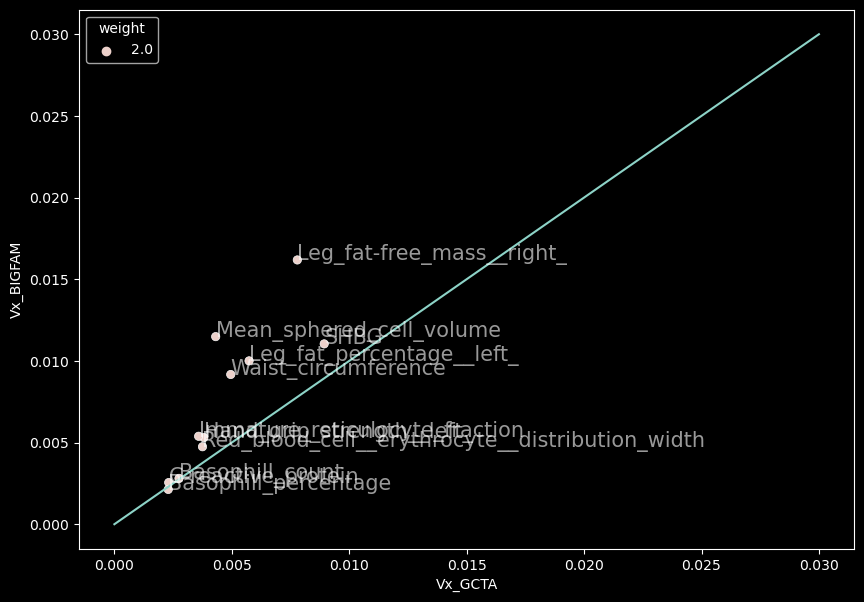

In [176]:
fig, ax = plt.subplots(figsize=(10, 7))

for_plot = df_mrg[df_mrg["weight"] == 2] #[(df_mrg["weight"] >= 1) & (df_mrg["weight"] < 4)],
sns.scatterplot(
    data=for_plot,
    x="Vx_GCTA",
    y="Vx_BIGFAM",
    hue="weight",
    ax=ax
)


ax.plot([0, 0.03], [0, 0.03])

for i, pheno in enumerate(for_plot["pheno"]):
    x = for_plot.loc[for_plot["pheno"] == pheno, "Vx_GCTA"].values[0]
    y = for_plot.loc[for_plot["pheno"] == pheno, "Vx_BIGFAM"].values[0]
    ax.annotate(pheno, (x, y), fontsize=15, alpha=0.6)

In [177]:
# regression & correlation
df_reg = pd.DataFrame(
    columns=[
        "weight", "n_pheno",
        "slope", "se_slope",
        "corr", "se_corr"
    ]
)

for weight in sorted(df_mrg["weight"].unique()):
    tmp = df_mrg[df_mrg["weight"] == weight].copy()
    
    ll = smf.ols(
        formula="Vx_BIGFAM ~ 0 + Vx_GCTA",
        data=tmp
    ).fit()
    
    # corr
    corrs = []
    for pheno in tmp["pheno"].unique():
        tmp_remove_one = tmp[tmp["pheno"] != pheno]
        corr = tmp_remove_one[["Vx_GCTA", "Vx_BIGFAM"]].corr().iloc[0, 1]
        corrs += [corr]
    
    df_reg.loc[len(df_reg)] = [
        weight, ll.nobs,
        ll.params["Vx_GCTA"], ll.bse["Vx_GCTA"], 
        np.mean(corrs), np.std(corrs)
    ]
df_reg

,weight,n_pheno,slope,se_slope,corr,se_corr
0,-2.0,12.0,17.893308,4.581625,-0.273613,1.501975e-01
1,-1.0,13.0,12.562434,3.044560,-0.298936,1.290814e-01
2,-0.0,12.0,7.110379,1.369973,-0.019984,1.803952e-01
3,1.0,13.0,3.174995,0.228600,0.844007,2.744515e-02
4,2.0,11.0,1.639689,0.142098,0.859744,3.560970e-02
5,3.0,14.0,0.893230,0.114140,0.840875,3.173580e-02
6,4.0,10.0,0.457645,0.123098,0.740437,7.413005e-02
7,5.0,8.0,0.331845,0.101043,0.654385,1.264339e-01
8,6.0,4.0,0.232906,0.095121,-0.112814,7.121118e-01
9,7.0,3.0,0.208140,0.042898,0.333333,9.428090e-01


(-1.0, 5.0)

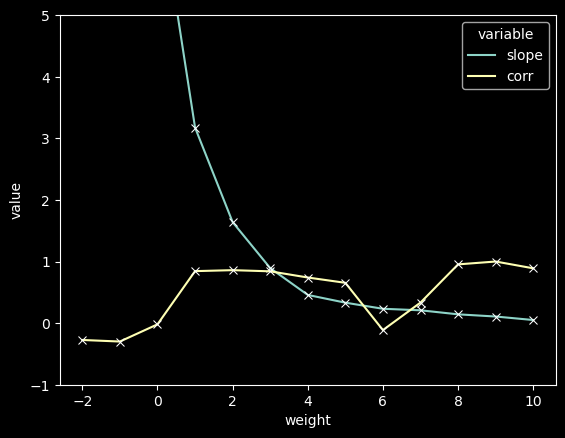

In [187]:
sns.lineplot(
    data=pd.melt(
        frame=df_reg,
        id_vars="weight",
        value_vars=["slope", "corr"]
    ),
    x="weight",
    y="value",
    hue="variable",
    marker="x"
)
plt.ylim([-1, 5])

## for X histogram

In [6]:
df_ukb

,pheno,true_weight,eta,lower_eta,upper_eta,alpha,lower_alpha,upper_alpha,X,lower_X,upper_X
0,Eosinophill_count,-10.0,0.280624,0.226375,0.335547,330303.530116,55278.055371,2.829562e+06,1.181545e-08,-1.250787e-07,5.534094e-07
1,Eosinophill_count,-9.0,0.279614,0.201920,0.332611,95712.567925,20116.335795,1.799706e+06,5.942466e-08,-2.882967e-07,1.563837e-06
2,Eosinophill_count,-8.0,0.276988,0.206314,0.339866,28862.221224,5623.765192,3.076930e+05,9.278152e-08,-1.245641e-06,5.425212e-06
3,Eosinophill_count,-7.0,0.263867,0.204111,0.329129,11233.979800,2390.231399,6.775408e+04,6.297171e-08,-6.013328e-06,8.910569e-06
4,Eosinophill_count,-6.0,0.274093,0.204053,0.332283,2358.422534,742.986291,1.386058e+04,1.149324e-06,-1.460141e-05,3.533032e-05
...,...,...,...,...,...,...,...,...,...,...,...
1399,Lymphocyte_count,-2.0,0.354749,0.297966,0.404402,7.946154,6.116279,1.126453e+01,4.002975e-03,-8.299480e-04,1.014182e-02
1400,Lymphocyte_count,-1.0,0.343641,0.287811,0.412385,2.910018,2.425238,3.474500e+00,1.153626e-02,-1.402412e-03,2.218143e-02
1401,Lymphocyte_count,0.0,0.350018,0.293615,0.417412,1.000000,1.000000,1.000000e+00,2.039183e-02,-9.215776e-03,4.421156e-02
1402,Lymphocyte_count,1.0,0.358294,0.282742,0.429129,0.358294,0.282742,4.291292e-01,3.909470e-02,-9.022172e-03,9.612799e-02


# Step 6. XmXf

In [8]:
df_ukb = pd.read_csv(
    "/data/jerrylee/pjt/BIGFAM.v.0.1/data/UKB/obj2/XmXf.raw.tsv",
    sep='\t'
)

df_ukb_formatted = pd.DataFrame(
    columns=[
        "pheno", "weight", "eta", 
        "Vx_male_BIGFAM", "lower_Vx_male_BIGFAM", "upper_Vx_male_BIGFAM",
        "Vx_female_BIGFAM", "lower_Vx_female_BIGFAM", "upper_Vx_female_BIGFAM",
    ]
)

for pheno in df_ukb["pheno"].unique():
    for weight in sorted(df_ukb["true_weight"].unique()):
        tmp = (
            df_ukb[
                (df_ukb["pheno"] == pheno)
                & (df_ukb["true_weight"] == weight)
                ]
            .copy()
            .reset_index(drop=True)
        )
        
        eta = np.mean(df_ukb[(df_ukb["pheno"] == pheno)]["eta"])
        df_ukb_formatted.loc[len(df_ukb_formatted)] = [
            pheno, -weight, eta,
            tmp["Xmale"].values[0], tmp["lower_Xmale"].values[0], tmp["upper_Xmale"].values[0],
            tmp["Xfemale"].values[0], tmp["lower_Xfemale"].values[0], tmp["upper_Xfemale"].values[0],
        ]
        
df_ukb_formatted

,pheno,weight,eta,Vx_male_BIGFAM,lower_Vx_male_BIGFAM,upper_Vx_male_BIGFAM,Vx_female_BIGFAM,lower_Vx_female_BIGFAM,upper_Vx_female_BIGFAM
0,Eosinophill_count,10.0,0.276460,0.000001,0.000001,0.000001,0.000001,0.000001,0.000001
1,Eosinophill_count,9.0,0.276460,0.000001,0.000001,0.000002,0.000001,0.000001,0.000001
2,Eosinophill_count,8.0,0.276460,0.000001,0.000001,0.000004,0.000001,0.000001,0.000001
3,Eosinophill_count,7.0,0.276460,0.000001,0.000001,0.000013,0.000001,0.000001,0.000001
4,Eosinophill_count,6.0,0.276460,0.000003,0.000001,0.000054,0.000001,0.000001,0.000005
...,...,...,...,...,...,...,...,...,...
1399,Lymphocyte_count,2.0,0.351841,0.006456,0.002093,0.012155,0.000012,0.000001,0.001414
1400,Lymphocyte_count,1.0,0.351841,0.020730,0.007335,0.031052,0.000881,0.000001,0.004900
1401,Lymphocyte_count,-0.0,0.351841,0.044536,0.021841,0.072432,0.001125,0.000001,0.005602
1402,Lymphocyte_count,-1.0,0.351841,0.091109,0.046055,0.144321,0.000261,0.000001,0.012067


In [35]:
df_ukb_formatted[df_ukb_formatted["pheno"] == "Weight"]

,pheno,weight,eta,Vx_male_BIGFAM,lower_Vx_male_BIGFAM,upper_Vx_male_BIGFAM,Vx_female_BIGFAM,lower_Vx_female_BIGFAM,upper_Vx_female_BIGFAM
507,Weight,10.0,0.622014,0.000108,0.000001,0.000892,0.000039,0.000001,0.000217
508,Weight,9.0,0.622014,0.000179,0.000001,0.001370,0.000052,0.000001,0.000362
509,Weight,8.0,0.622014,0.000350,0.000001,0.002008,0.000081,0.000001,0.000656
510,Weight,7.0,0.622014,0.000368,0.000001,0.003074,0.000086,0.000001,0.001048
511,Weight,6.0,0.622014,0.000936,0.000001,0.004118,0.000232,0.000001,0.001898
512,Weight,5.0,0.622014,0.001518,0.000001,0.006158,0.000338,0.000001,0.002782
513,Weight,4.0,0.622014,0.002438,0.000001,0.007839,0.000850,0.000001,0.003840
514,Weight,3.0,0.622014,0.003433,0.000001,0.013975,0.000865,0.000001,0.008274
515,Weight,2.0,0.622014,0.003701,0.000001,0.018687,0.001120,0.000001,0.008748
516,Weight,1.0,0.622014,0.008161,0.000001,0.025709,0.004670,0.000001,0.012617


In [2]:
# df_ukb_formatted = pd.read_csv(
#     "/data/jerrylee/pjt/BIGFAM.v.0.1/data/UKB/obj2/XmXf_rgrid.tsv",
#     sep='\t'
# )


# df_ukb_formatted = pd.DataFrame(
#     columns=[
#         "pheno", "weight", "eta", 
#         "Vx_male_BIGFAM", "lower_Vx_male_BIGFAM", "upper_Vx_male_BIGFAM",
#         "Vx_female_BIGFAM", "lower_Vx_female_BIGFAM", "upper_Vx_female_BIGFAM",
#         "r", "lower_r", "upper_r"
#     ]
# )

# for pheno in df_ukb["pheno"].unique():
#     for weight in sorted(df_ukb["true_weight"].unique()):
#         tmp = (
#             df_ukb[
#                 (df_ukb["pheno"] == pheno)
#                 & (df_ukb["true_weight"] == weight)
#                 ]
#             .copy()
#             .reset_index(drop=True)
#         )
        
#         tmp_mins = tmp.iloc[tmp.groupby("block_idx").idxmin()["func_val"]]
        
#         df_ukb_formatted.loc[len(df_ukb_formatted)] = [
#             pheno, -weight, tmp_mins["eta"].mean(),
#             np.median(tmp_mins["Xmale"]), np.percentile(tmp_mins["Xmale"], 2.5), np.percentile(tmp_mins["Xmale"], 97.5),
#             np.median(tmp_mins["Xfemale"]), np.percentile(tmp_mins["Xfemale"], 2.5), np.percentile(tmp_mins["Xfemale"], 97.5),
#             np.median(tmp_mins["r"]), np.percentile(tmp_mins["r"], 2.5), np.percentile(tmp_mins["r"], 97.5),
#         ]

,pheno,true_weight,eta,lower_eta,upper_eta,alpha,lower_alpha,upper_alpha,Xmale,lower_Xmale,upper_Xmale,Xfemale,lower_Xfemale,upper_Xfemale
0,Eosinophill_count,-10.0,0.274367,0.216527,0.341744,413713.591720,46299.812185,4.428588e+06,0.000001,0.000001,0.000001,0.000001,0.000001,0.000001
1,Eosinophill_count,-9.0,0.276602,0.216310,0.332441,105532.204073,20210.070326,9.957910e+05,0.000001,0.000001,0.000002,0.000001,0.000001,0.000001
2,Eosinophill_count,-8.0,0.275170,0.206331,0.333714,30425.471418,6501.446481,3.063599e+05,0.000001,0.000001,0.000004,0.000001,0.000001,0.000001
3,Eosinophill_count,-7.0,0.280651,0.225102,0.340273,7292.161508,1893.624908,3.415578e+04,0.000001,0.000001,0.000013,0.000001,0.000001,0.000001
4,Eosinophill_count,-6.0,0.276296,0.220217,0.340048,2248.631509,647.054863,8.787840e+03,0.000003,0.000001,0.000054,0.000001,0.000001,0.000005
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1399,Lymphocyte_count,-2.0,0.342021,0.284005,0.401969,8.548609,6.189017,1.241212e+01,0.006456,0.002093,0.012155,0.000012,0.000001,0.001414
1400,Lymphocyte_count,-1.0,0.354378,0.291052,0.422076,2.821861,2.369241,3.436013e+00,0.020730,0.007335,0.031052,0.000881,0.000001,0.004900
1401,Lymphocyte_count,0.0,0.348390,0.285660,0.401645,1.000000,1.000000,1.000000e+00,0.044536,0.021841,0.072432,0.001125,0.000001,0.005602
1402,Lymphocyte_count,1.0,0.349488,0.289312,0.408330,0.349488,0.289312,4.083301e-01,0.091109,0.046055,0.144321,0.000261,0.000001,0.012067


In [189]:
df_gs = pd.read_csv(
    "/data/jerrylee/pjt/BIGFAM.v.0.1/data/GS/obj2/XmXf.tsv",
    sep='\t'
)

In [9]:
df_gcta = pd.read_csv(
    "/data/jerrylee/pjt/BIGFAM.v.0.1/data/GCTA/X.all.gcta",
    sep='\t'
)
df_gcta["lower_X_GCTA"] = df_gcta["X_GCTA"] - 1.96 * df_gcta["se_X_GCTA"] 
df_gcta["upper_X_GCTA"] = df_gcta["X_GCTA"] + 1.96 * df_gcta["se_X_GCTA"] 

tmp_male = (
    df_gcta
    .loc[
        df_gcta["sex"] == "male",
        ["pheno", "X_GCTA", "lower_X_GCTA", "upper_X_GCTA"]
    ]
    .rename(columns={
        "X_GCTA": "Vx_male_GCTA", 
        "lower_X_GCTA": "lower_Vx_male_GCTA", 
        "upper_X_GCTA": "upper_Vx_male_GCTA", 
    })
    .copy()
)

tmp_female = (
    df_gcta
    .loc[
        df_gcta["sex"] == "female",
        ["pheno", "X_GCTA", "lower_X_GCTA", "upper_X_GCTA"]
    ]
    .rename(columns={
        "X_GCTA": "Vx_female_GCTA", 
        "lower_X_GCTA": "lower_Vx_female_GCTA", 
        "upper_X_GCTA": "upper_Vx_female_GCTA", 
    })
    .copy()
)

df_gcta_formatted = pd.merge(
    tmp_male,
    tmp_female,
    on=["pheno"]
)

## for X correlation

In [23]:
# left nonzero phenotypes
thred = 1e-6

df_ukb_filtered = (
    df_ukb_formatted[
        (df_ukb_formatted["Vx_male_BIGFAM"] > thred)
        & (df_ukb_formatted["Vx_female_BIGFAM"] > thred)
    ]
    .copy()
)
df_gcta_filtered = (
    df_gcta_formatted[
        (df_gcta_formatted["Vx_male_GCTA"] > thred)
        & (df_gcta_formatted["Vx_female_GCTA"] > thred)
    ]
    .copy()
)

In [30]:
# merge BIGFAM & GCTA (UKB)
df_mrg = pd.merge(
    df_ukb_filtered,
    df_gcta_filtered,
    on="pheno"
)

df_mrg["DCR_BIGFAM"] = df_mrg["Vx_male_BIGFAM"] / df_mrg["Vx_female_BIGFAM"] 
df_mrg["DCR_GCTA"] = df_mrg["Vx_male_GCTA"] / df_mrg["Vx_female_GCTA"] 

df_mrg = df_mrg[~df_mrg["pheno"].isin([
    # "Monocyte_count",
    # "Red_blood_cell__erythrocyte__count",
    # "Forced_vital_capacity__FVC_,_Best_measure"
    ])]

len(df_mrg["pheno"].unique())

19

In [31]:
sorted(df_mrg["pheno"].unique())

['Arm_fat_mass__left_',
 'Arm_fat_mass__right_',
 'Body_fat_percentage',
 'Body_mass_index__BMI_',
 'HDL_cholesterol',
 'Hand_grip_strength__left_',
 'Immature_reticulocyte_fraction',
 'Leg_fat-free_mass__right_',
 'Leg_fat_mass__left_',
 'Leg_fat_percentage__left_',
 'Lymphocyte_percentage',
 'Mean_corpuscular_haemoglobin',
 'Mean_platelet__thrombocyte__volume',
 'Mean_sphered_cell_volume',
 'Monocyte_count',
 'Platelet_crit',
 'SHBG',
 'Waist_circumference',
 'Whole_body_fat_mass']

In [32]:
# regression & correlation
df_reg = pd.DataFrame(
    columns=[
        "weight", "n_pheno",
        "slope_male", "se_slope_male",
        "corr_male", "se_corr_male",
        "slope_female", "se_slope_female",
        "corr_female", "se_corr_female",
    ]
)

for weight in sorted(df_mrg["weight"].unique()):
    tmp = df_mrg[df_mrg["weight"] == weight].copy()
    
    ll_male = smf.ols(
        formula="Vx_male_BIGFAM ~ 0 + Vx_male_GCTA",
        data=tmp
    ).fit()
    
    ll_female = smf.ols(
        formula="Vx_female_BIGFAM ~ 0 + Vx_female_GCTA",
        data=tmp
    ).fit()
    
    
    # corr
    corrs_male = []
    corrs_female = []
    for pheno in tmp["pheno"].unique():
        tmp_remove_one = tmp[tmp["pheno"] != pheno]
        corr_male = (tmp_remove_one[["Vx_male_BIGFAM", "Vx_male_GCTA"]]
                     .corr()
                     .iloc[0, 1])
        corr_female = (tmp_remove_one[["Vx_female_BIGFAM", "Vx_female_GCTA"]]
                     .corr()
                     .iloc[0, 1])
        
        corrs_male += [corr_male]
        corrs_female += [corr_female]
    
    df_reg.loc[len(df_reg)] = [
        weight, ll_male.nobs,
        ll_male.params["Vx_male_GCTA"], ll_male.bse["Vx_male_GCTA"], 
        np.mean(corrs_male), np.std(corrs_male),
        ll_female.params["Vx_female_GCTA"], ll_female.bse["Vx_female_GCTA"], 
        np.mean(corrs_female), np.std(corrs_female),
    ]
df_reg

/home/jerrylee/miniconda3/envs/BIGFAM/lib/python3.9/site-packages/statsmodels/regression/linear_model.py:1716: RuntimeWarning: invalid value encountered in scalar divide
  return np.dot(wresid, wresid) / self.df_resid


,weight,n_pheno,slope_male,se_slope_male,corr_male,se_corr_male,slope_female,se_slope_female,corr_female,se_corr_female
0,-2.0,14.0,4.467849,1.125409,-0.374144,1.337966e-01,7.189322,1.226990,-0.274956,0.024258
1,-1.0,13.0,4.307660,0.668732,0.430002,1.887681e-01,5.566331,0.742082,0.400342,0.125530
2,-0.0,7.0,2.667658,0.485491,0.507934,2.165899e-01,3.615379,0.366733,0.764516,0.126111
3,1.0,2.0,1.503018,0.728705,NaN,NaN,1.674497,0.134579,NaN,NaN
4,2.0,2.0,0.687177,0.433052,NaN,NaN,0.728252,0.289908,NaN,NaN
5,3.0,2.0,0.133341,0.005180,NaN,NaN,0.214608,0.005552,NaN,NaN
6,4.0,3.0,0.171649,0.107283,-1.000000,0.000000e+00,0.173737,0.068623,0.333333,0.942809
7,5.0,1.0,0.016702,NaN,NaN,NaN,0.022705,NaN,NaN,NaN
8,6.0,2.0,0.042447,0.043487,NaN,NaN,0.045414,0.020682,NaN,NaN
9,7.0,3.0,0.043185,0.034610,-1.000000,1.812987e-16,0.029973,0.016356,-0.333333,0.942809


<Axes: xlabel='weight', ylabel='value'>

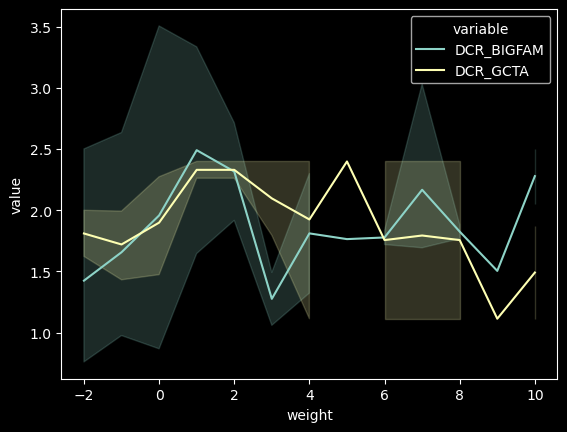

In [33]:
sns.lineplot(
    data=pd.melt(
        frame=df_mrg,
        id_vars=["weight"],
        value_vars=["DCR_BIGFAM", "DCR_GCTA"]
    ),
    x="weight",
    y="value",
    hue="variable"
)

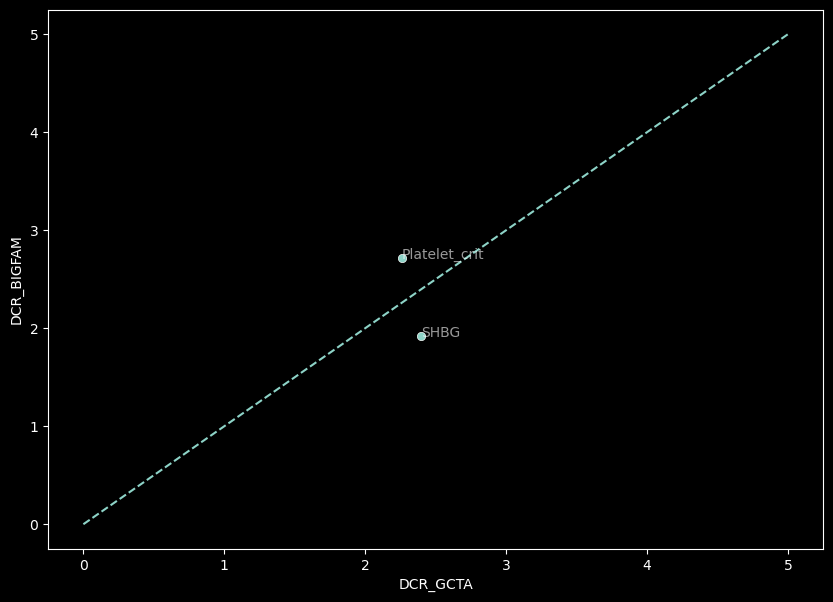

In [34]:
fig, ax = plt.subplots(figsize=(10, 7))

for_plot = df_mrg[df_mrg["weight"] == 2]
sns.scatterplot(
    data=for_plot,
    x="DCR_GCTA",
    y="DCR_BIGFAM", 
    ax=ax
)
ax.plot([0, 5], [0, 5], ls="--")


for i, pheno in enumerate(for_plot["pheno"]):
    x = for_plot.loc[for_plot["pheno"] == pheno, "DCR_GCTA"].values[0]
    y = for_plot.loc[for_plot["pheno"] == pheno, "DCR_BIGFAM"].values[0]
    ax.annotate(pheno, (x, y), fontsize=10, alpha=0.6)